# FER Model Training — MATH 8335 Deep Learning
## Facial Emotion Recognition: Custom CNN · ResNet-50 · ViT-B/16

**Before running:**
1. Runtime → Change runtime type → **GPU (A100)**
2. Upload `rafdb_prep_config.pkl` and the `RAF-DB/` folder to your Google Drive
3. Update `DRIVE_ROOT` in Cell 1 to match your Drive path
4. Run all cells top to bottom — do not skip any cell

**Outputs saved to Drive:**
- `best_cnn.pth`, `best_resnet.pth`, `best_vit.pth` — best model weights
- `history_cnn.pkl`, `history_resnet.pkl`, `history_vit.pkl` — training histories
- All figures as `.png` files ready to include in the report

## Cell 0 — Mount Drive and install dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'transformers', 'timm', '--quiet'], check=True)

print('Drive mounted. Dependencies ready.')

Mounted at /content/drive
Drive mounted. Dependencies ready.


## Cell 1 — Paths and global seed

In [2]:
import os, random, pickle, time, copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc, classification_report
)
from PIL import Image
from transformers import ViTForImageClassification

# ── Reproducibility functions — must be defined before loading config ──────
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# ── Update this to your Google Drive folder ────────────────────────────────
DRIVE_ROOT  = '/content/drive/MyDrive/FER_Project'   # <-- change if needed
DATA_ROOT   = os.path.join(DRIVE_ROOT, 'RAF-DB')
CONFIG_PATH = os.path.join(DRIVE_ROOT, 'rafdb_prep_config.pkl')
OUTPUT_DIR  = os.path.join(DRIVE_ROOT, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load prep config (skip the pickled functions, use local ones above) ────
cfg = pickle.load(open(CONFIG_PATH, 'rb'))
SEED        = cfg['SEED']
CLASS_NAMES = cfg['CLASS_NAMES']
NUM_CLASSES = cfg['NUM_CLASSES']
IMAGE_SIZE  = cfg['IMAGE_SIZE']
BATCH_SIZE  = cfg['BATCH_SIZE']
TRAIN_MEAN  = cfg['TRAIN_MEAN']
TRAIN_STD   = cfg['TRAIN_STD']
train_counts = cfg['train_counts']

# ── Re-apply all seeds ─────────────────────────────────────────────────────
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device        : {device}')
print(f'Seed          : {SEED}')
print(f'Classes       : {CLASS_NAMES}')
print(f'Image size    : {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'Output dir    : {OUTPUT_DIR}')
assert device.type == 'cuda', 'GPU not detected — change runtime to GPU before proceeding!'

Device        : cuda
Seed          : 42
Classes       : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Image size    : 224x224
Output dir    : /content/drive/MyDrive/FER_Project/outputs


## Cell 2 — Transforms, dataset splits, DataLoaders

In [3]:
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.RandomCrop(IMAGE_SIZE, padding=10, padding_mode='reflect'),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

# ── Dataset class that allows different transforms on val subset ───────────
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __getitem__(self, idx):
        img_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), label
    def __len__(self):
        return len(self.subset)

# ── Build datasets ─────────────────────────────────────────────────────────
set_seed(SEED)   # re-seed before split so split is identical every run
full_train   = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR,  transform=val_test_transform)

n_total = len(full_train)
n_val   = int(0.10 * n_total)
n_train = n_total - n_val

train_subset, val_subset = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
val_dataset = TransformSubset(val_subset, val_test_transform)

# ── Each DataLoader gets its own seeded generator ─────────────────────────
# Sharing a single generator object causes the loaders to consume each
# other's random state. Each must be independently seeded.
def make_loader(dataset, shuffle, batch_size):
    g = torch.Generator()
    g.manual_seed(SEED)
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle,
        num_workers=2, pin_memory=True,
        worker_init_fn=seed_worker, generator=g
    )

train_loader = make_loader(train_subset, shuffle=True,  batch_size=BATCH_SIZE)
val_loader   = make_loader(val_dataset,  shuffle=False, batch_size=BATCH_SIZE)
test_loader  = make_loader(test_dataset, shuffle=False, batch_size=BATCH_SIZE)

# ── Class-weighted loss computed from the actual training subset ───────────
# train_counts in cfg reflects the full 12,271-image folder. After the 90/10
# split the subset has 11,044 images, so we recompute from the split indices.
from collections import Counter
train_labels_list = [full_train.targets[i] for i in train_subset.indices]
subset_counts = Counter(train_labels_list)
N_train = len(train_labels_list)
class_weights = torch.tensor([
    N_train / (NUM_CLASSES * subset_counts[i])
    for i in range(NUM_CLASSES)
], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f'Train : {n_train:,}  Val : {n_val:,}  Test : {len(test_dataset):,}')
print(f'Class weights (subset): {[round(w.item(),4) for w in class_weights]}')

Train : 11,044  Val : 1,227  Test : 3,068
Class weights (subset): [2.5043, 2.4423, 6.2608, 0.3673, 0.6923, 0.8814, 1.3695]


## Cell 3 — Shared training utilities

In [4]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        # ViT returns a SequenceClassifierOutput object
        if hasattr(outputs, 'logits'):
            outputs = outputs.logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += imgs.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        if hasattr(outputs, 'logits'):
            outputs = outputs.logits
        loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    loss_avg = running_loss / total
    acc      = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return loss_avg, acc, macro_f1


def train_model(model, model_name, train_loader, val_loader,
                optimizer, scheduler, criterion, device,
                max_epochs=100, patience=10, save_path='best.pth'):
    """
    Full training loop with early stopping on val macro-F1.
    Returns history dict with lists: train_loss, val_loss, train_acc,
    val_acc, val_f1, and scalar best_val_f1 and epochs_trained.
    """
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}
    best_val_f1   = 0.0
    best_weights  = copy.deepcopy(model.state_dict())
    no_improve    = 0
    start_time    = time.time()

    for epoch in range(1, max_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_acc, v_f1 = evaluate(model, val_loader, criterion, device)

        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['val_f1'].append(v_f1)

        print(f'[{model_name}] Epoch {epoch:02d}/{max_epochs} '
              f'| train_loss {t_loss:.4f}  val_loss {v_loss:.4f} '
              f'| val_acc {v_acc:.4f}  val_macro-F1 {v_f1:.4f}')

        if v_f1 > best_val_f1:
            best_val_f1  = v_f1
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch} (no improvement for {patience} epochs).')
                break

    elapsed = time.time() - start_time
    model.load_state_dict(best_weights)   # restore best
    history['best_val_f1']    = best_val_f1
    history['epochs_trained'] = epoch
    history['training_time_s']= elapsed
    print(f'  Training complete in {elapsed/60:.1f} min. Best val macro-F1: {best_val_f1:.4f}')
    return history


def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


print('Training utilities ready.')

Training utilities ready.


## Cell 4 — Model 1: Custom CNN
Architecture: 4 conv blocks (32→64→128→256) + GAP + FC(256) + Dropout(0.5) + 7-class softmax  
He initialization, trained from scratch, ~500K parameters

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),   # 224 -> 112
            ConvBlock(32,  64),   # 112 ->  56
            ConvBlock(64,  128),  #  56 ->  28
            ConvBlock(128, 256),  #  28 ->  14
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)   # 14 -> 1x1x256
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        # He initialization for Conv and Linear layers
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.head(x)


# ── Instantiate and check ──────────────────────────────────────────────────
set_seed(SEED)
cnn_model = CustomCNN(num_classes=NUM_CLASSES).to(device)
total_p, train_p = count_parameters(cnn_model)
print(f'Custom CNN — Total: {total_p:,}  Trainable: {train_p:,}')

# Quick forward pass check
with torch.no_grad():
    dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    out = cnn_model(dummy)
    assert out.shape == (2, NUM_CLASSES), f'Unexpected output shape: {out.shape}'
print('Forward pass check passed.')

Custom CNN — Total: 456,487  Trainable: 456,487
Forward pass check passed.


## Cell 5 — Train Custom CNN

In [6]:
set_seed(SEED)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
cnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer, mode='min', factor=0.5, patience=5
)

cnn_save_path = os.path.join(OUTPUT_DIR, 'best_cnn.pth')
history_cnn = train_model(
    model       = cnn_model,
    model_name  = 'Custom CNN',
    train_loader= train_loader,
    val_loader  = val_loader,
    optimizer   = cnn_optimizer,
    scheduler   = cnn_scheduler,
    criterion   = criterion,
    device      = device,
    max_epochs  = 100,
    patience    = 10,
    save_path   = cnn_save_path
)

# Save history
with open(os.path.join(OUTPUT_DIR, 'history_cnn.pkl'), 'wb') as f:
    pickle.dump(history_cnn, f)
print('CNN history saved.')

[Custom CNN] Epoch 01/100 | train_loss 1.9654  val_loss 1.8464 | val_acc 0.3725  val_macro-F1 0.1683
[Custom CNN] Epoch 02/100 | train_loss 1.9019  val_loss 1.8499 | val_acc 0.3953  val_macro-F1 0.1769
[Custom CNN] Epoch 03/100 | train_loss 1.8968  val_loss 1.8303 | val_acc 0.3773  val_macro-F1 0.1854
[Custom CNN] Epoch 04/100 | train_loss 1.8937  val_loss 1.8717 | val_acc 0.3969  val_macro-F1 0.1924
[Custom CNN] Epoch 05/100 | train_loss 1.8891  val_loss 1.9098 | val_acc 0.3839  val_macro-F1 0.1505
[Custom CNN] Epoch 06/100 | train_loss 1.8821  val_loss 1.8448 | val_acc 0.3871  val_macro-F1 0.1785
[Custom CNN] Epoch 07/100 | train_loss 1.8846  val_loss 1.8516 | val_acc 0.3439  val_macro-F1 0.1989
[Custom CNN] Epoch 08/100 | train_loss 1.8842  val_loss 1.8311 | val_acc 0.3692  val_macro-F1 0.1757
[Custom CNN] Epoch 09/100 | train_loss 1.8800  val_loss 1.8157 | val_acc 0.3684  val_macro-F1 0.1627
[Custom CNN] Epoch 10/100 | train_loss 1.8735  val_loss 1.8228 | val_acc 0.3749  val_macro-

## Cell 6 — Model 2: ResNet-50 with Transfer Learning
Stem + Layers 1–3 frozen (11.6M). Layer 4 + new head trainable (~14M).

In [7]:
set_seed(SEED)
resnet_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# ── Freeze stem and layers 1–3 ────────────────────────────────────────────
frozen_modules = [resnet_model.conv1, resnet_model.bn1,
                  resnet_model.maxpool,
                  resnet_model.layer1, resnet_model.layer2, resnet_model.layer3]
for module in frozen_modules:
    for param in module.parameters():
        param.requires_grad = False

# ── Replace classification head: 2048 -> 7 ────────────────────────────────
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, NUM_CLASSES)
nn.init.kaiming_normal_(resnet_model.fc.weight, nonlinearity='relu')
nn.init.zeros_(resnet_model.fc.bias)

resnet_model = resnet_model.to(device)
total_p, train_p = count_parameters(resnet_model)
print(f'ResNet-50 — Total: {total_p:,}  Trainable: {train_p:,}')

# Quick forward pass check
with torch.no_grad():
    dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    out = resnet_model(dummy)
    assert out.shape == (2, NUM_CLASSES)
print('Forward pass check passed.')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 239MB/s]


ResNet-50 — Total: 23,522,375  Trainable: 14,979,079
Forward pass check passed.


## Cell 7 — Train ResNet-50

In [8]:
set_seed(SEED)
resnet_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
resnet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer, mode='min', factor=0.5, patience=5
)

resnet_save_path = os.path.join(OUTPUT_DIR, 'best_resnet.pth')
history_resnet = train_model(
    model       = resnet_model,
    model_name  = 'ResNet-50',
    train_loader= train_loader,
    val_loader  = val_loader,
    optimizer   = resnet_optimizer,
    scheduler   = resnet_scheduler,
    criterion   = criterion,
    device      = device,
    max_epochs  = 100,
    patience    = 10,
    save_path   = resnet_save_path
)

with open(os.path.join(OUTPUT_DIR, 'history_resnet.pkl'), 'wb') as f:
    pickle.dump(history_resnet, f)
print('ResNet history saved.')

[ResNet-50] Epoch 01/100 | train_loss 1.6538  val_loss 1.3931 | val_acc 0.4556  val_macro-F1 0.3988
[ResNet-50] Epoch 02/100 | train_loss 1.2973  val_loss 1.1759 | val_acc 0.5990  val_macro-F1 0.5326
[ResNet-50] Epoch 03/100 | train_loss 1.1126  val_loss 1.0861 | val_acc 0.5884  val_macro-F1 0.5262
[ResNet-50] Epoch 04/100 | train_loss 0.9929  val_loss 1.0187 | val_acc 0.6333  val_macro-F1 0.5473
[ResNet-50] Epoch 05/100 | train_loss 0.9143  val_loss 1.0603 | val_acc 0.6577  val_macro-F1 0.5694
[ResNet-50] Epoch 06/100 | train_loss 0.8014  val_loss 1.0192 | val_acc 0.7025  val_macro-F1 0.6092
[ResNet-50] Epoch 07/100 | train_loss 0.7471  val_loss 1.0226 | val_acc 0.7042  val_macro-F1 0.6054
[ResNet-50] Epoch 08/100 | train_loss 0.6599  val_loss 1.0443 | val_acc 0.6993  val_macro-F1 0.6248
[ResNet-50] Epoch 09/100 | train_loss 0.6313  val_loss 0.9789 | val_acc 0.7156  val_macro-F1 0.6274
[ResNet-50] Epoch 10/100 | train_loss 0.5721  val_loss 0.9977 | val_acc 0.7253  val_macro-F1 0.6476


## Cell 8 — Model 3: ViT-B/16 with Transfer Learning
Blocks 1–9 frozen (64M). Blocks 10–12 + head trainable (~22M).  
Differential learning rates: 1e-5 for fine-tuned blocks, 1e-4 for new head.

In [9]:
set_seed(SEED)
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

# ── Freeze all parameters first ───────────────────────────────────────────
for param in vit_model.parameters():
    param.requires_grad = False

# ── Unfreeze transformer blocks 10, 11, 12 (0-indexed: 9, 10, 11) ────────
for block_idx in [9, 10, 11]:
    for param in vit_model.vit.encoder.layer[block_idx].parameters():
        param.requires_grad = True

# ── Unfreeze the classifier head ──────────────────────────────────────────
for param in vit_model.classifier.parameters():
    param.requires_grad = True

# ── Unfreeze post-encoder layer norm (sits between encoder and classifier) ─
for param in vit_model.vit.layernorm.parameters():
    param.requires_grad = True

# He initialization for the new head
nn.init.kaiming_normal_(vit_model.classifier.weight, nonlinearity='relu')
nn.init.zeros_(vit_model.classifier.bias)

vit_model = vit_model.to(device)
total_p, train_p = count_parameters(vit_model)
print(f'ViT-B/16 — Total: {total_p:,}  Trainable: {train_p:,}')

# Quick forward pass check
with torch.no_grad():
    dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    out = vit_model(dummy)
    assert out.logits.shape == (2, NUM_CLASSES)
print('Forward pass check passed.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViT-B/16 — Total: 85,804,039  Trainable: 21,270,535
Forward pass check passed.


## Cell 9 — Train ViT-B/16

In [10]:
set_seed(SEED)

# Differential learning rates: lower for fine-tuned blocks, higher for new head
vit_block_params = []
for block_idx in [9, 10, 11]:
    vit_block_params += list(vit_model.vit.encoder.layer[block_idx].parameters())

vit_optimizer = torch.optim.Adam([
    {'params': vit_block_params +
               list(vit_model.vit.layernorm.parameters()), 'lr': 1e-5},
    {'params': vit_model.classifier.parameters(),           'lr': 1e-4}
], weight_decay=1e-4)

vit_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    vit_optimizer, mode='min', factor=0.5, patience=5
)

vit_save_path = os.path.join(OUTPUT_DIR, 'best_vit.pth')
history_vit = train_model(
    model       = vit_model,
    model_name  = 'ViT-B/16',
    train_loader= train_loader,
    val_loader  = val_loader,
    optimizer   = vit_optimizer,
    scheduler   = vit_scheduler,
    criterion   = criterion,
    device      = device,
    max_epochs  = 100,
    patience    = 10,
    save_path   = vit_save_path
)

with open(os.path.join(OUTPUT_DIR, 'history_vit.pkl'), 'wb') as f:
    pickle.dump(history_vit, f)
print('ViT history saved.')

[ViT-B/16] Epoch 01/100 | train_loss 1.8002  val_loss 1.5793 | val_acc 0.5819  val_macro-F1 0.4530
[ViT-B/16] Epoch 02/100 | train_loss 1.5230  val_loss 1.3659 | val_acc 0.6210  val_macro-F1 0.4995
[ViT-B/16] Epoch 03/100 | train_loss 1.3744  val_loss 1.2486 | val_acc 0.6333  val_macro-F1 0.5182
[ViT-B/16] Epoch 04/100 | train_loss 1.2834  val_loss 1.1894 | val_acc 0.6528  val_macro-F1 0.5335
[ViT-B/16] Epoch 05/100 | train_loss 1.2159  val_loss 1.1390 | val_acc 0.6610  val_macro-F1 0.5557
[ViT-B/16] Epoch 06/100 | train_loss 1.1560  val_loss 1.1135 | val_acc 0.6585  val_macro-F1 0.5545
[ViT-B/16] Epoch 07/100 | train_loss 1.1073  val_loss 1.0675 | val_acc 0.6740  val_macro-F1 0.5802
[ViT-B/16] Epoch 08/100 | train_loss 1.0621  val_loss 1.0492 | val_acc 0.6813  val_macro-F1 0.5895
[ViT-B/16] Epoch 09/100 | train_loss 1.0404  val_loss 1.0254 | val_acc 0.6985  val_macro-F1 0.6166
[ViT-B/16] Epoch 10/100 | train_loss 0.9987  val_loss 1.0045 | val_acc 0.6944  val_macro-F1 0.6082
[ViT-B/16]

## Cell 10 — Full test-set evaluation (all three models)

In [11]:
@torch.no_grad()
def full_evaluate(model, loader, device, num_classes):
    """
    Returns:
      preds, labels (numpy arrays)
      probs: softmax probabilities (N x num_classes) for ROC curves
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        if hasattr(outputs, 'logits'):
            outputs = outputs.logits
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


models_info = [
    ('Custom CNN',  cnn_model),
    ('ResNet-50',   resnet_model),
    ('ViT-B/16',    vit_model),
]

results = {}
for name, model in models_info:
    preds, labels, probs = full_evaluate(model, test_loader, device, NUM_CLASSES)
    results[name] = {'preds': preds, 'labels': labels, 'probs': probs}
    acc       = accuracy_score(labels, preds)
    macro_f1  = f1_score(labels, preds, average='macro',     zero_division=0)
    macro_prec= precision_score(labels, preds, average='macro', zero_division=0)
    macro_rec = recall_score(labels, preds, average='macro',  zero_division=0)
    results[name].update({'acc': acc, 'macro_f1': macro_f1,
                          'macro_prec': macro_prec, 'macro_rec': macro_rec})
    print(f'{name:<12} Acc={acc:.4f}  Macro-F1={macro_f1:.4f}  '
          f'Prec={macro_prec:.4f}  Rec={macro_rec:.4f}')

# Save results
with open(os.path.join(OUTPUT_DIR, 'test_results.pkl'), 'wb') as f:
    pickle.dump(results, f)
print('Test results saved.')

Custom CNN   Acc=0.6154  Macro-F1=0.5217  Prec=0.5241  Rec=0.5335
ResNet-50    Acc=0.7718  Macro-F1=0.6939  Prec=0.6938  Rec=0.6969
ViT-B/16     Acc=0.7096  Macro-F1=0.6041  Prec=0.5865  Rec=0.6333
Test results saved.


## Cell 11 — Figure 1: Training and validation loss curves

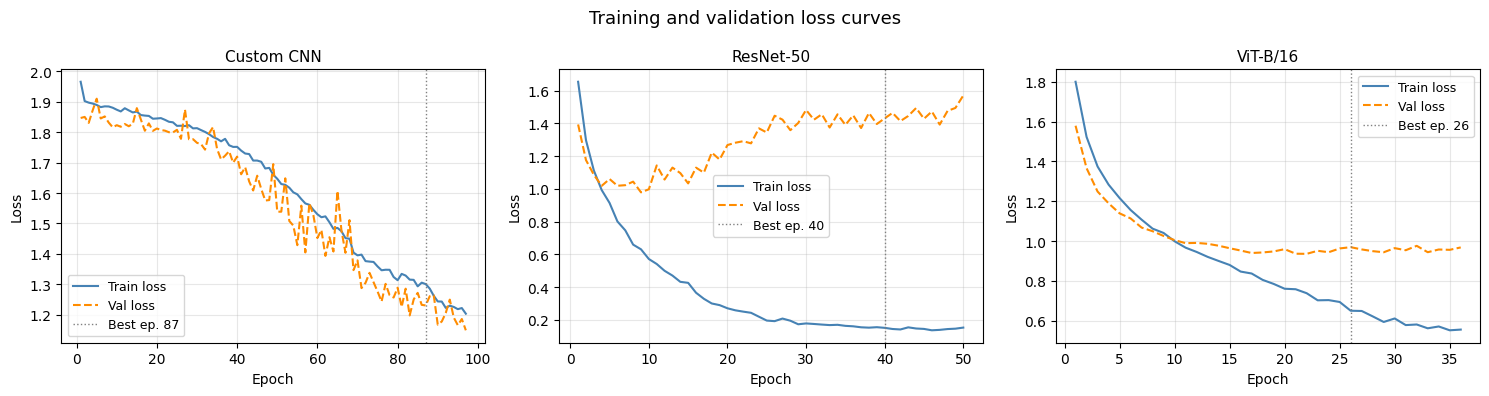

Saved: /content/drive/MyDrive/FER_Project/outputs/loss_curves.pdf


In [35]:
histories = {
    'Custom CNN': history_cnn,
    'ResNet-50':  history_resnet,
    'ViT-B/16':   history_vit,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('Training and validation loss curves', fontsize=13)

for ax, (name, h) in zip(axes, histories.items()):
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='Train loss', color='steelblue',  linewidth=1.5)
    ax.plot(epochs, h['val_loss'],   label='Val loss',   color='darkorange', linewidth=1.5, linestyle='--')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    best_ep = int(np.argmax(h['val_f1'])) + 1   # best checkpoint = peak val macro-F1
    ax.axvline(best_ep, color='gray', linestyle=':', linewidth=1, label=f'Best ep. {best_ep}')
    ax.legend(fontsize=9)

plt.tight_layout()
loss_fig_path = os.path.join(OUTPUT_DIR, 'loss_curves.pdf')
plt.savefig(
    loss_fig_path,
    format='pdf',
    bbox_inches='tight',
    transparent=True
)
plt.show()
print(f'Saved: {loss_fig_path}')

## Cell 12 — Figure 2: Validation macro-F1 per epoch (appendix)

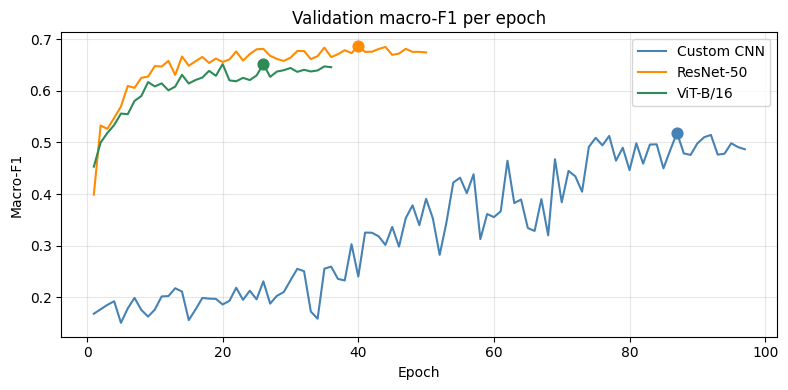

Saved: /content/drive/MyDrive/FER_Project/outputs/val_f1_curves.pdf


In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = {'Custom CNN': 'steelblue', 'ResNet-50': 'darkorange', 'ViT-B/16': 'seagreen'}

for name, h in histories.items():
    epochs = range(1, len(h['val_f1']) + 1)
    ax.plot(epochs, h['val_f1'], label=name, color=colors[name], linewidth=1.5)
    best_f1 = h['best_val_f1']
    best_ep = int(np.argmax(h['val_f1'])) + 1
    ax.scatter(best_ep, best_f1, color=colors[name], s=60, zorder=5)

ax.set_title('Validation macro-F1 per epoch', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro-F1')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
f1_fig_path = os.path.join(OUTPUT_DIR, 'val_f1_curves.pdf')
plt.savefig(
    f1_fig_path,
    format='pdf',
    bbox_inches='tight',
    transparent=True
)
plt.show()
print(f'Saved: {f1_fig_path}')

## Cell 13 — Figure 3: Confusion matrices (normalized)

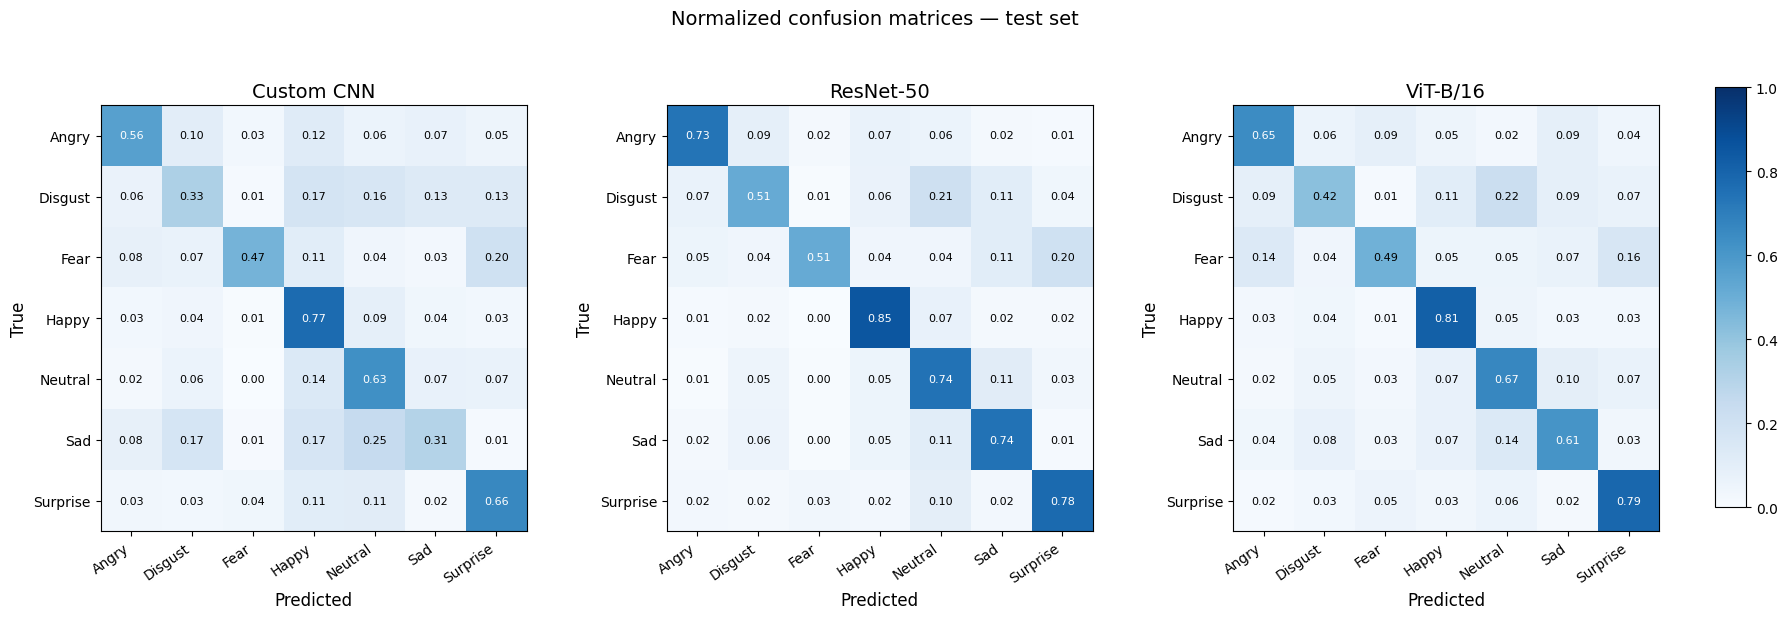

Saved: /content/drive/MyDrive/FER_Project/outputs/confusion_matrices.pdf


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Normalized confusion matrices — test set', fontsize=14)

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['labels'], r['preds'], normalize='true')

    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)

    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))

    short_names = [c.capitalize() for c in CLASS_NAMES]

    ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=10)
    ax.set_yticklabels(short_names, fontsize=10)

    ax.set_title(name, fontsize=14)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)

    # Keep values inside cells
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            color = 'white' if cm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i, j]:.2f}',
                    ha='center', va='center',
                    fontsize=8, color=color)

# 🔥 Create space on the right for colorbar
plt.subplots_adjust(wspace=0.25, right=0.88, top=0.82)

# 🔥 Add colorbar in its own axis (no overlap)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax)

# Save
cm_fig_path = os.path.join(OUTPUT_DIR, 'confusion_matrices.pdf')
plt.savefig(
    cm_fig_path,
    format='pdf',
    bbox_inches='tight',
    transparent=True
)

plt.show()
print(f'Saved: {cm_fig_path}')

## Cell 14 — Figure 4: ROC curves (one-vs-rest)

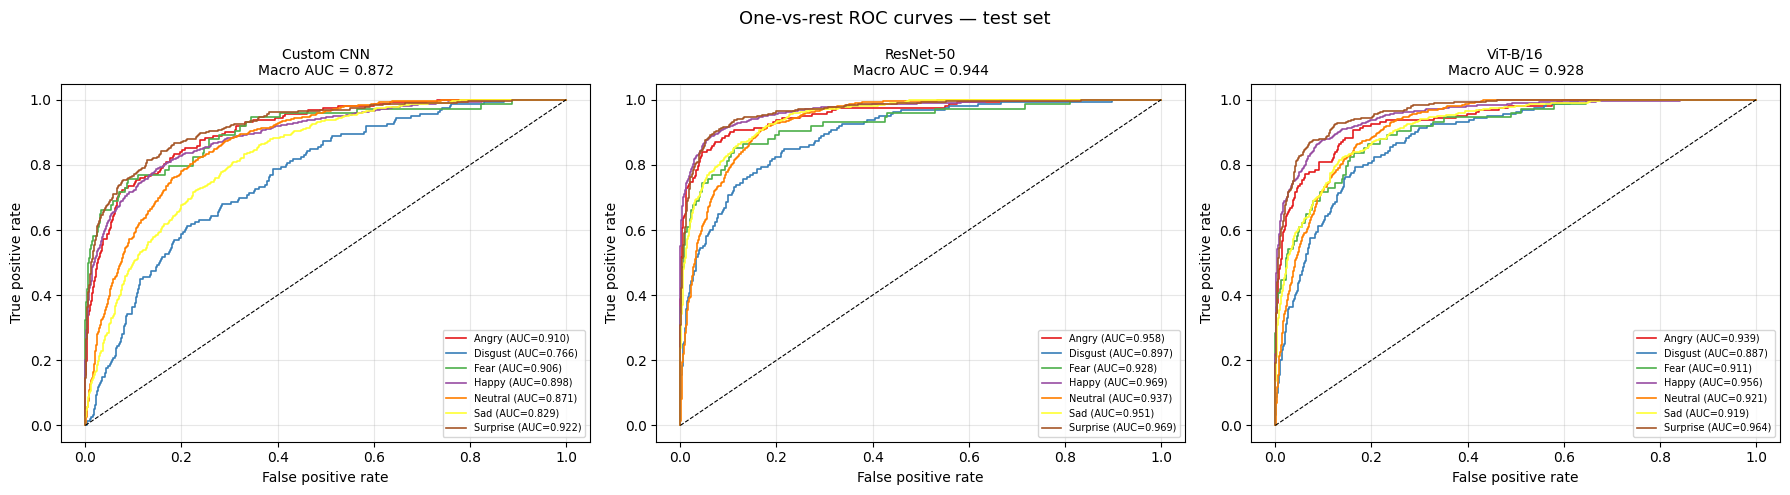


ROC-AUC Summary:
  Custom CNN: Macro AUC = 0.8717
    angry     : 0.9098
    disgust   : 0.7658
    fear      : 0.9057
    happy     : 0.8983
    neutral   : 0.8711
    sad       : 0.8294
    surprise  : 0.9222
  ResNet-50: Macro AUC = 0.9443
    angry     : 0.9585
    disgust   : 0.8974
    fear      : 0.9279
    happy     : 0.9694
    neutral   : 0.9367
    sad       : 0.9511
    surprise  : 0.9687
  ViT-B/16: Macro AUC = 0.9282
    angry     : 0.9393
    disgust   : 0.8866
    fear      : 0.9112
    happy     : 0.9555
    neutral   : 0.9214
    sad       : 0.9190
    surprise  : 0.9644
Saved: /content/drive/MyDrive/FER_Project/outputs/roc_curves.pdf


In [31]:
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('One-vs-rest ROC curves — test set', fontsize=13)
line_colors = plt.cm.Set1.colors

roc_summary = {}   # store AUC values for the results table

for ax, (name, r) in zip(axes, results.items()):
    y_bin = label_binarize(r['labels'], classes=list(range(NUM_CLASSES)))
    macro_auc_vals = []
    class_aucs = {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], r['probs'][:, i])
        roc_auc = auc(fpr, tpr)
        macro_auc_vals.append(roc_auc)
        class_aucs[cls] = roc_auc
        ax.plot(fpr, tpr, lw=1.2, color=line_colors[i],
                label=f'{cls.capitalize()} (AUC={roc_auc:.3f})')
    macro_auc = np.mean(macro_auc_vals)
    roc_summary[name] = {'macro_auc': macro_auc, 'class_aucs': class_aucs}
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f'{name}\nMacro AUC = {macro_auc:.3f}', fontsize=10)
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
roc_fig_path = os.path.join(OUTPUT_DIR, 'roc_curves.pdf')
plt.savefig(roc_fig_path, bbox_inches='tight')
plt.show()

# Print AUC summary
print('\nROC-AUC Summary:')
for name, vals in roc_summary.items():
    print(f'  {name}: Macro AUC = {vals["macro_auc"]:.4f}')
    for cls, a in vals['class_aucs'].items():
        print(f'    {cls:<10}: {a:.4f}')
print(f'Saved: {roc_fig_path}')

## Cell 15 — Per-class F1 scores (all models)

In [16]:
print('Per-class F1 scores on test set')
print(f'{"Emotion":<12}', end='')
for name in results:
    print(f'  {name:<14}', end='')
print()
print('-' * 60)

per_class_f1 = {}
for name, r in results.items():
    f1s = f1_score(r['labels'], r['preds'], average=None, zero_division=0)
    per_class_f1[name] = {cls: f1s[i] for i, cls in enumerate(CLASS_NAMES)}

for cls in CLASS_NAMES:
    print(f'{cls.capitalize():<12}', end='')
    for name in results:
        print(f'  {per_class_f1[name][cls]:.4f}        ', end='')
    print()

print('-' * 60)
print(f'{"Macro-F1":<12}', end='')
for name, r in results.items():
    print(f'  {r["macro_f1"]:.4f}        ', end='')
print()

# Save per-class F1
with open(os.path.join(OUTPUT_DIR, 'per_class_f1.pkl'), 'wb') as f:
    pickle.dump(per_class_f1, f)

Per-class F1 scores on test set
Emotion       Custom CNN      ResNet-50       ViT-B/16      
------------------------------------------------------------
Angry         0.4959          0.7104          0.5850        
Disgust       0.2518          0.4713          0.3691        
Fear          0.4930          0.5588          0.3731        
Happy         0.7738          0.8842          0.8482        
Neutral       0.6117          0.7218          0.6848        
Sad           0.3858          0.7348          0.6432        
Surprise      0.6402          0.7763          0.7255        
------------------------------------------------------------
Macro-F1      0.5217          0.6939          0.6041        


## Cell 16 — Full results summary (for the report tables)

In [17]:
print('='*75)
print('COMPLETE RESULTS SUMMARY — copy these into the report')
print('='*75)

print('\n--- Table 2: Overall Performance ---')
print(f'{"Model":<14} {"Accuracy":>10} {"Macro-F1":>10} {"Macro-Prec":>12} {"Macro-Rec":>12}')
print('-'*62)
for name, r in results.items():
    print(f'{name:<14} {r["acc"]:>10.4f} {r["macro_f1"]:>10.4f} '
          f'{r["macro_prec"]:>12.4f} {r["macro_rec"]:>12.4f}')

print('\n--- Table 3: Per-class F1 ---')
header = f'{"Emotion":<12}' + ''.join(f'{n:>14}' for n in results)
print(header)
print('-'*54)
for cls in CLASS_NAMES:
    row = f'{cls.capitalize():<12}'
    for name in results:
        row += f'{per_class_f1[name][cls]:>14.4f}'
    print(row)

print('\n--- Table 4: Model Complexity and Efficiency ---')
print(f'{"Property":<26} {"Custom CNN":>12} {"ResNet-50":>12} {"ViT-B/16":>12}')
print('-'*66)

def fmt_params(n):
    return f'{n/1e6:.1f}M' if n >= 1e6 else f'{n/1e3:.0f}K'

cnn_total,  cnn_train  = count_parameters(cnn_model)
res_total,  res_train  = count_parameters(resnet_model)
vit_total,  vit_train  = count_parameters(vit_model)

rows = [
    ('Total parameters',    fmt_params(cnn_total),  fmt_params(res_total),  fmt_params(vit_total)),
    ('Trainable parameters',fmt_params(cnn_train),  fmt_params(res_train),  fmt_params(vit_train)),
    ('Epochs trained',      str(history_cnn['epochs_trained']),
                            str(history_resnet['epochs_trained']),
                            str(history_vit['epochs_trained'])),
    ('Training time (min)', f"{history_cnn['training_time_s']/60:.1f}",
                            f"{history_resnet['training_time_s']/60:.1f}",
                            f"{history_vit['training_time_s']/60:.1f}"),
    ('Best val macro-F1',   f"{history_cnn['best_val_f1']:.4f}",
                            f"{history_resnet['best_val_f1']:.4f}",
                            f"{history_vit['best_val_f1']:.4f}"),
]
for prop, c, r, v in rows:
    print(f'{prop:<26} {c:>12} {r:>12} {v:>12}')

print('\n--- ROC-AUC Summary ---')
for name, vals in roc_summary.items():
    print(f'{name}: Macro AUC = {vals["macro_auc"]:.4f}')

print('\n' + '='*75)

COMPLETE RESULTS SUMMARY — copy these into the report

--- Table 2: Overall Performance ---
Model            Accuracy   Macro-F1   Macro-Prec    Macro-Rec
--------------------------------------------------------------
Custom CNN         0.6154     0.5217       0.5241       0.5335
ResNet-50          0.7718     0.6939       0.6938       0.6969
ViT-B/16           0.7096     0.6041       0.5865       0.6333

--- Table 3: Per-class F1 ---
Emotion         Custom CNN     ResNet-50      ViT-B/16
------------------------------------------------------
Angry               0.4959        0.7104        0.5850
Disgust             0.2518        0.4713        0.3691
Fear                0.4930        0.5588        0.3731
Happy               0.7738        0.8842        0.8482
Neutral             0.6117        0.7218        0.6848
Sad                 0.3858        0.7348        0.6432
Surprise            0.6402        0.7763        0.7255

--- Table 4: Model Complexity and Efficiency ---
Property         

## Cell 17 — Sample predictions grid (appendix figure)

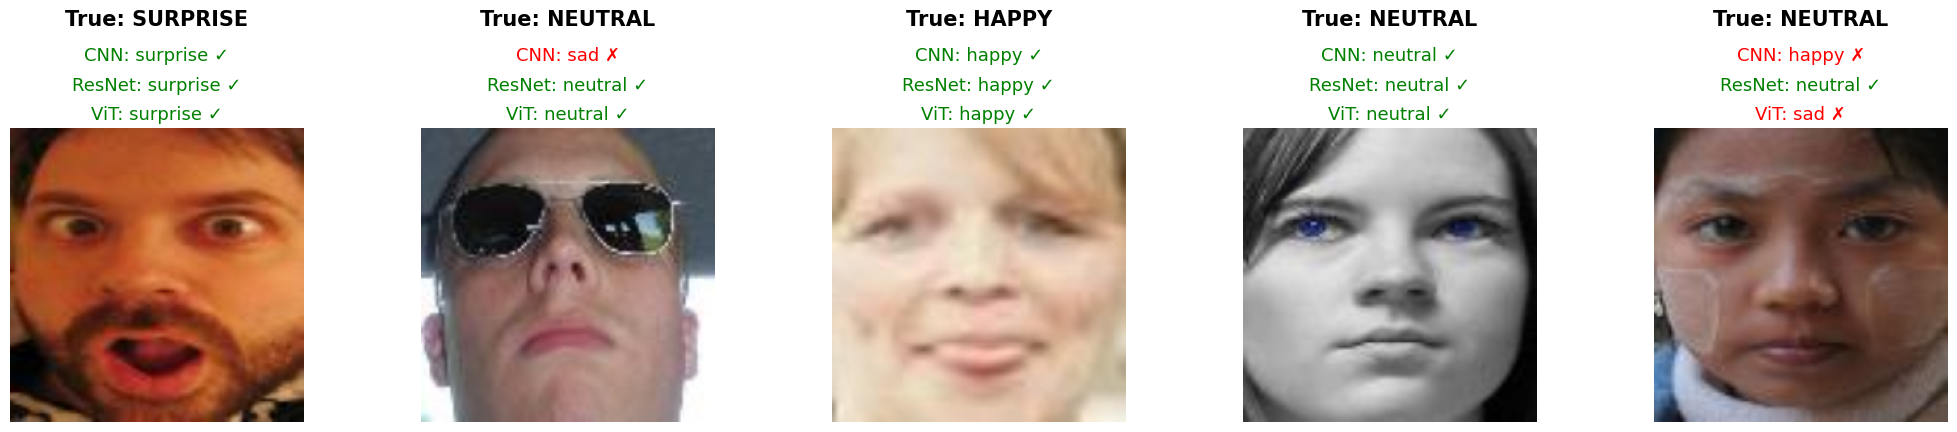

Saved: /content/drive/MyDrive/FER_Project/outputs/sample_predictions.pdf


In [32]:
def unnormalize(tensor):
    m = torch.tensor(TRAIN_MEAN).view(3, 1, 1)
    s = torch.tensor(TRAIN_STD).view(3, 1, 1)
    return (tensor * s + m).clamp(0, 1)


set_seed(SEED)

sample_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(SEED)
)

sample_imgs, sample_labels = next(iter(sample_loader))


with torch.no_grad():
    cnn_out = cnn_model(sample_imgs.to(device)).argmax(1).cpu()
    res_out = resnet_model(sample_imgs.to(device)).argmax(1).cpu()
    vit_out = vit_model(sample_imgs.to(device)).logits.argmax(1).cpu()


n_show = 5
fig, axes = plt.subplots(1, n_show, figsize=(25, 6))
axes = axes.flatten()

for i in range(n_show):
    img_np = unnormalize(sample_imgs[i]).permute(1, 2, 0).numpy()

    true_cls = CLASS_NAMES[sample_labels[i]]
    cnn_cls  = CLASS_NAMES[cnn_out[i]]
    res_cls  = CLASS_NAMES[res_out[i]]
    vit_cls  = CLASS_NAMES[vit_out[i]]

    ax = axes[i]
    ax.imshow(img_np)
    ax.axis('off')

    def plot_line(y, text, correct, size=13, weight='normal'):
        ax.text(
            0.5, y,
            text,
            transform=ax.transAxes,
            ha='center',
            fontsize=size,
            color='green' if correct else 'red',
            fontweight=weight
        )

    ax.text(0.5, 1.35, f"True: {true_cls.upper()}",
        transform=ax.transAxes,
        ha='center',
        fontsize=15,
        fontweight='bold',
        color='black')

    plot_line(1.23, f"CNN: {cnn_cls} {'✓' if cnn_cls == true_cls else '✗'}",
          cnn_cls == true_cls)

    plot_line(1.13, f"ResNet: {res_cls} {'✓' if res_cls == true_cls else '✗'}",
          res_cls == true_cls)

    plot_line(1.03, f"ViT: {vit_cls} {'✓' if vit_cls == true_cls else '✗'}",
          vit_cls == true_cls)

    plt.subplots_adjust(wspace=0.4, top=0.7)

pred_fig_path = os.path.join(OUTPUT_DIR, 'sample_predictions.pdf')
plt.savefig(
    pred_fig_path,
    format='pdf',
    bbox_inches='tight',
    transparent=True
)

plt.show()
print(f"Saved: {pred_fig_path}")

## Cell 18 — Classification reports (full per-class precision/recall/F1)

In [19]:
for name, r in results.items():
    print(f'\n{"="*55}')
    print(f'{name} — Full classification report')
    print('='*55)
    print(classification_report(
        r['labels'], r['preds'],
        target_names=[c.capitalize() for c in CLASS_NAMES],
        digits=4
    ))


Custom CNN — Full classification report
              precision    recall  f1-score   support

       Angry     0.4439    0.5617    0.4959       162
     Disgust     0.2055    0.3250    0.2518       160
        Fear     0.5147    0.4730    0.4930        74
       Happy     0.7754    0.7722    0.7738      1185
     Neutral     0.5923    0.6324    0.6117       680
         Sad     0.5176    0.3075    0.3858       478
    Surprise     0.6193    0.6626    0.6402       329

    accuracy                         0.6154      3068
   macro avg     0.5241    0.5335    0.5217      3068
weighted avg     0.6244    0.6154    0.6144      3068


ResNet-50 — Full classification report
              precision    recall  f1-score   support

       Angry     0.6879    0.7346    0.7104       162
     Disgust     0.4362    0.5125    0.4713       160
        Fear     0.6129    0.5135    0.5588        74
       Happy     0.9167    0.8540    0.8842      1185
     Neutral     0.7008    0.7441    0.7218       6

## Cell 19 — Verify all output files saved to Drive

In [28]:
expected_files = [
    'best_cnn.pth', 'best_resnet.pth', 'best_vit.pth',
    'history_cnn.pkl', 'history_resnet.pkl', 'history_vit.pkl',
    'test_results.pkl', 'per_class_f1.pkl',
    'loss_curves.png', 'val_f1_curves.png',
    'confusion_matrices.png', 'roc_curves.png',
    'sample_predictions.png',
]

print('Output file check:')
all_ok = True
for fname in expected_files:
    path = os.path.join(OUTPUT_DIR, fname)
    exists = os.path.exists(path)
    size = os.path.getsize(path) / 1024 if exists else 0
    status = f'✓  {size:.1f} KB' if exists else '✗  MISSING'
    print(f'  {fname:<35} {status}')
    if not exists:
        all_ok = False

print()
if all_ok:
    print('All files saved successfully. You can now close Colab.')
else:
    print('Some files are missing — re-run the relevant cells.')

Output file check:
  best_cnn.pth                        ✓  1797.2 KB
  best_resnet.pth                     ✓  92196.1 KB
  best_vit.pth                        ✓  335250.8 KB
  history_cnn.pkl                     ✓  4.4 KB
  history_resnet.pkl                  ✓  2.4 KB
  history_vit.pkl                     ✓  1.7 KB
  test_results.pkl                    ✓  396.2 KB
  per_class_f1.pkl                    ✓  0.6 KB
  loss_curves.png                     ✓  146.3 KB
  val_f1_curves.png                   ✓  79.1 KB
  confusion_matrices.png              ✓  133.6 KB
  roc_curves.png                      ✓  165.5 KB
  sample_predictions.png              ✓  1200.8 KB

All files saved successfully. You can now close Colab.
